# Dataloader Visual Test
Sanity-check CUB, Cityscapes, and ADE20K dataloading end-to-end.
Each section checks: paths exist → dataset loads → geo-pair transform is aligned → batch collation works.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, SequentialSampler
import functools

In [2]:
from fusionLearning.config import CUB_IMAGES, CUB_SEGMENTATIONS, CITYSCAPES_ROOT, ADE20K_ROOT
from fusionLearning.data.dataloaders import (
    CUBDataset, CityscapesDataset, ADE20KDataset, pad_collate
)
from fusionLearning.data.aug import geoTransforms, photometricTransforms
from fusionLearning.data.vis import (
    visualize_geo_pair, visualize_geo_pair_samples, visualize_dataset_samples
)

## 0. Path check

In [3]:
paths = {
    "CUB images":      CUB_IMAGES,
    "CUB masks":       CUB_SEGMENTATIONS,
    "Cityscapes root": CITYSCAPES_ROOT,
    "ADE20K root":     ADE20K_ROOT,
}

available = {}
for name, path in paths.items():
    ok = os.path.exists(path)
    available[name] = ok
    print(f"{'[OK]' if ok else '[MISSING]':10s} {name}: {path}")

[OK]       CUB images: /home/cal390/fusionLearning/fusionLearning/data/CUBdata/CUB_200_2011/images
[OK]       CUB masks: /home/cal390/fusionLearning/fusionLearning/data/CUBdata/segmentations
[OK]       Cityscapes root: /home/cal390/fusionLearning/fusionLearning/data/cityscapes
[MISSING]  ADE20K root: /home/cal390/fusionLearning/fusionLearning/data/ADE20K


---
## 1. CUB-200-2011 (binary segmentation)

In [4]:
if not available["CUB images"]:
    print("CUB data not found — skipping")
else:
    cub_ds = CUBDataset(
        CUB_IMAGES, CUB_SEGMENTATIONS,
        gTransforms=geoTransforms,
        pTransforms=photometricTransforms,
    )
    print(f"CUB dataset: {len(cub_ds)} samples")

    img, mask, fname = cub_ds[0]
    print(f"  image  — shape: {img.shape}, dtype: {img.dtype}, range: [{img.min():.2f}, {img.max():.2f}]")
    print(f"  mask   — shape: {mask.shape}, dtype: {mask.dtype}, unique: {torch.unique(mask).tolist()}")
    print(f"  file   — {fname}")

Dataset loaded with 11788 image-segmentation pairs
CUB dataset: 11788 samples
  image  — shape: torch.Size([3, 192, 320]), dtype: torch.float32, range: [0.00, 0.87]
  mask   — shape: torch.Size([1, 192, 320]), dtype: torch.float32, unique: [0.0, 0.20000000298023224, 0.4000000059604645, 0.6000000238418579, 0.800000011920929, 1.0]
  file   — Black_Footed_Albatross_0001_796111.jpg


=== CUB geo-pair transform (3 random samples) ===


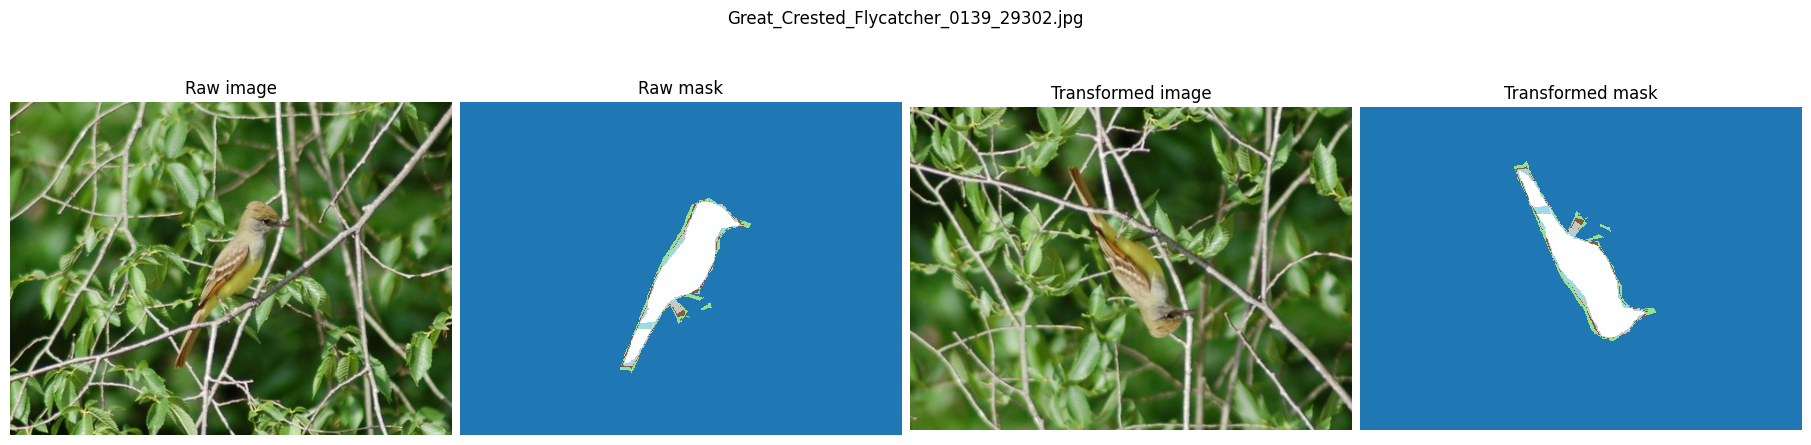

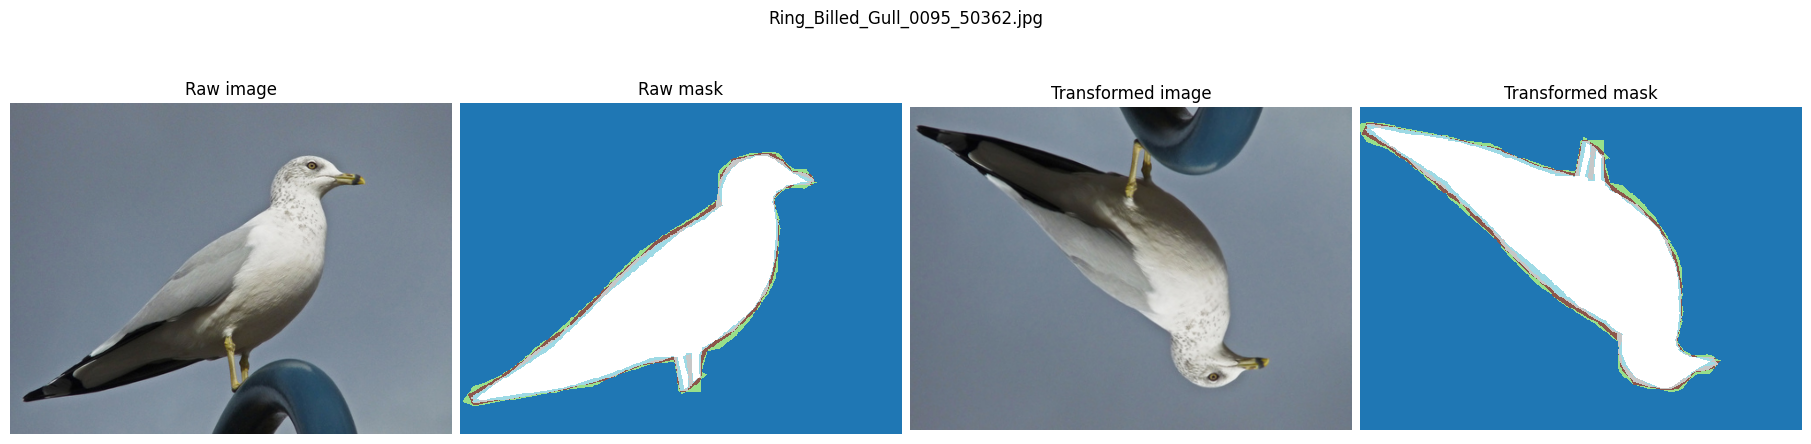

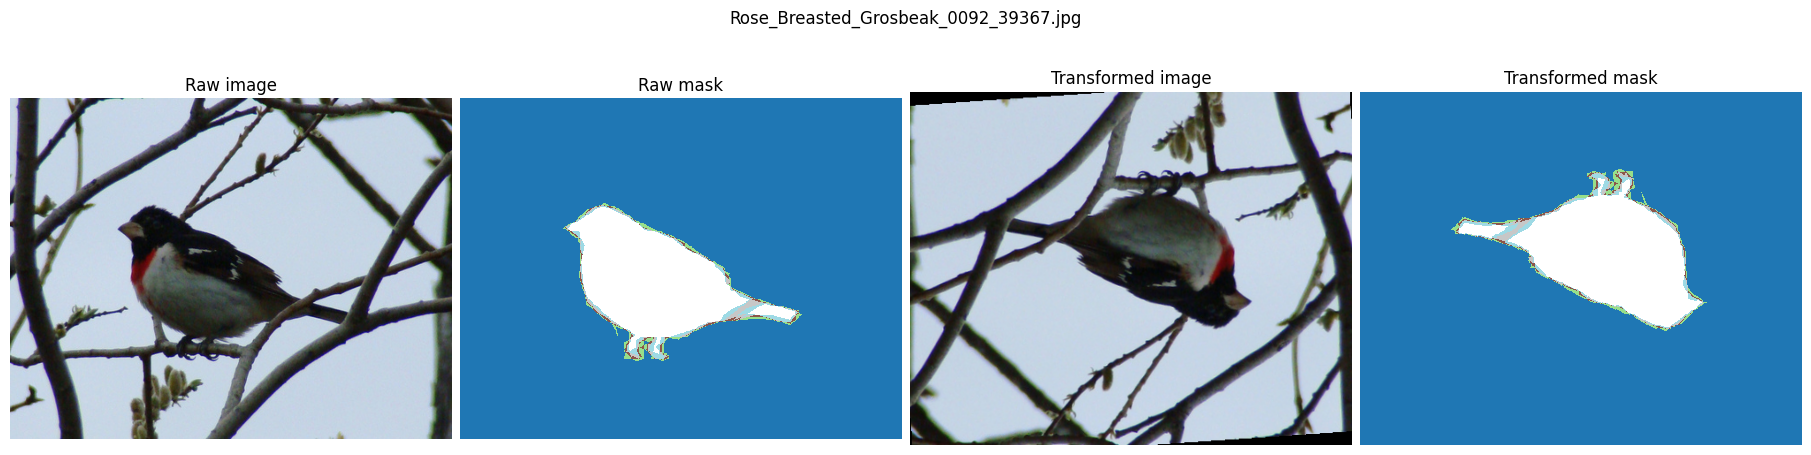

In [10]:
if available["CUB images"]:
    print("=== CUB geo-pair transform (3 random samples) ===")
    visualize_geo_pair_samples(cub_ds, num_samples=3, show=True)

=== CUB batch collation test ===
  batch images — torch.Size([4, 3, 352, 480])  dtype: torch.float32
  batch masks  — torch.Size([4, 1, 352, 480])  dtype: torch.float32
  filenames    — ['Black_Footed_Albatross_0001_796111.jpg', 'Black_Footed_Albatross_0002_55.jpg', 'Black_Footed_Albatross_0003_796136.jpg', 'Black_Footed_Albatross_0005_796090.jpg']


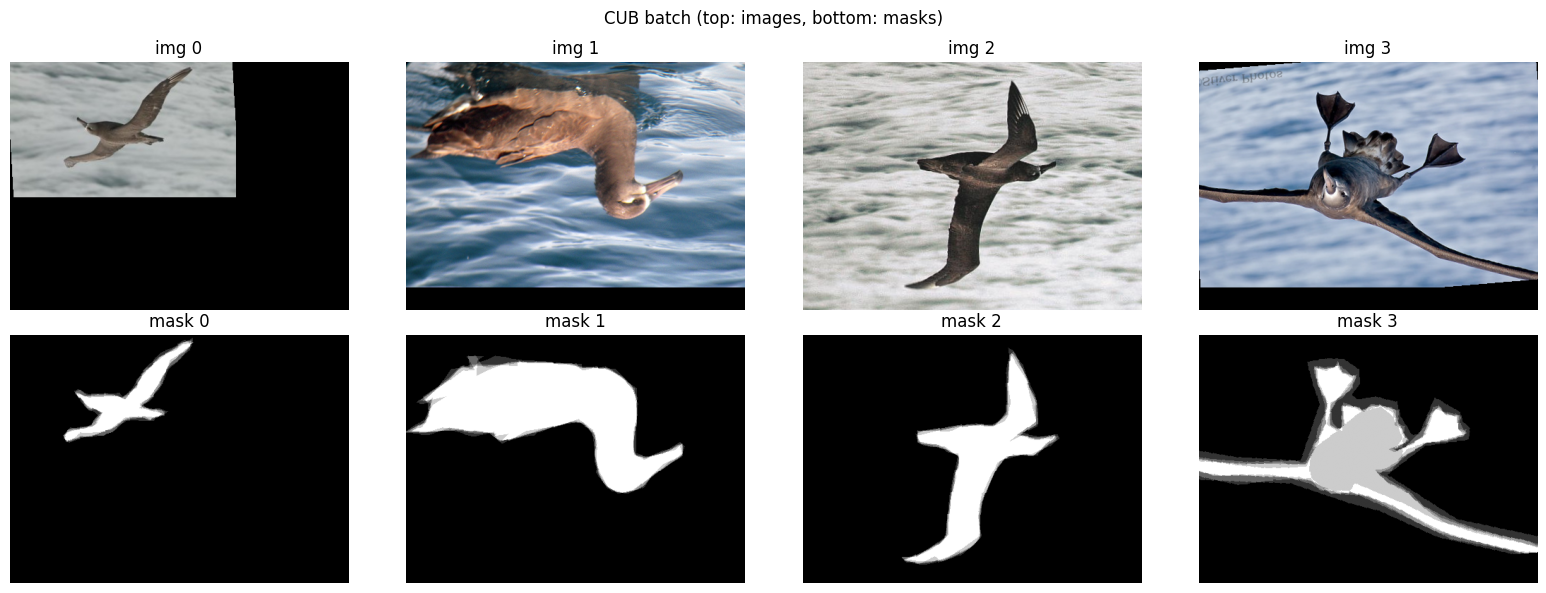

In [11]:
if available["CUB images"]:
    print("=== CUB batch collation test ===")
    cub_loader = DataLoader(
        cub_ds,
        batch_size=4,
        sampler=SequentialSampler(cub_ds),
        collate_fn=functools.partial(pad_collate, mask_pad_value=0),
    )
    imgs, masks, fnames = next(iter(cub_loader))
    print(f"  batch images — {imgs.shape}  dtype: {imgs.dtype}")
    print(f"  batch masks  — {masks.shape}  dtype: {masks.dtype}")
    print(f"  filenames    — {list(fnames)}")

    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    for i in range(4):
        axes[0, i].imshow(imgs[i].permute(1, 2, 0).clamp(0, 1))
        axes[0, i].set_title(f"img {i}")
        axes[0, i].axis("off")
        axes[1, i].imshow(masks[i].squeeze().numpy(), cmap="gray")
        axes[1, i].set_title(f"mask {i}")
        axes[1, i].axis("off")
    plt.suptitle("CUB batch (top: images, bottom: masks)")
    plt.tight_layout()
    plt.show()

---
## 2. Cityscapes (19-class semantic segmentation)

In [12]:
if not available["Cityscapes root"]:
    print("Cityscapes data not found — skipping")
else:
    cs_ds = CityscapesDataset(
        CITYSCAPES_ROOT, split="train",
        gTransforms=geoTransforms,
        pTransforms=photometricTransforms,
    )
    print(f"Cityscapes train: {len(cs_ds)} samples")

    img, mask, fname = cs_ds[0]
    print(f"  image  — shape: {img.shape}, dtype: {img.dtype}, range: [{img.min():.2f}, {img.max():.2f}]")
    print(f"  mask   — shape: {mask.shape}, dtype: {mask.dtype}")
    print(f"  unique class IDs: {torch.unique(mask).tolist()}")
    print(f"  file   — {fname}")

Cityscapes train: 2975 samples
  image  — shape: torch.Size([3, 1024, 2048]), dtype: torch.float32, range: [0.00, 1.00]
  mask   — shape: torch.Size([1024, 2048]), dtype: torch.int64
  unique class IDs: [0, 1, 2, 5, 7, 8, 10, 11, 13, 18, 255]
  file   — jena_000074_000019_leftImg8bit.png


=== Cityscapes geo-pair transform (3 random samples) ===


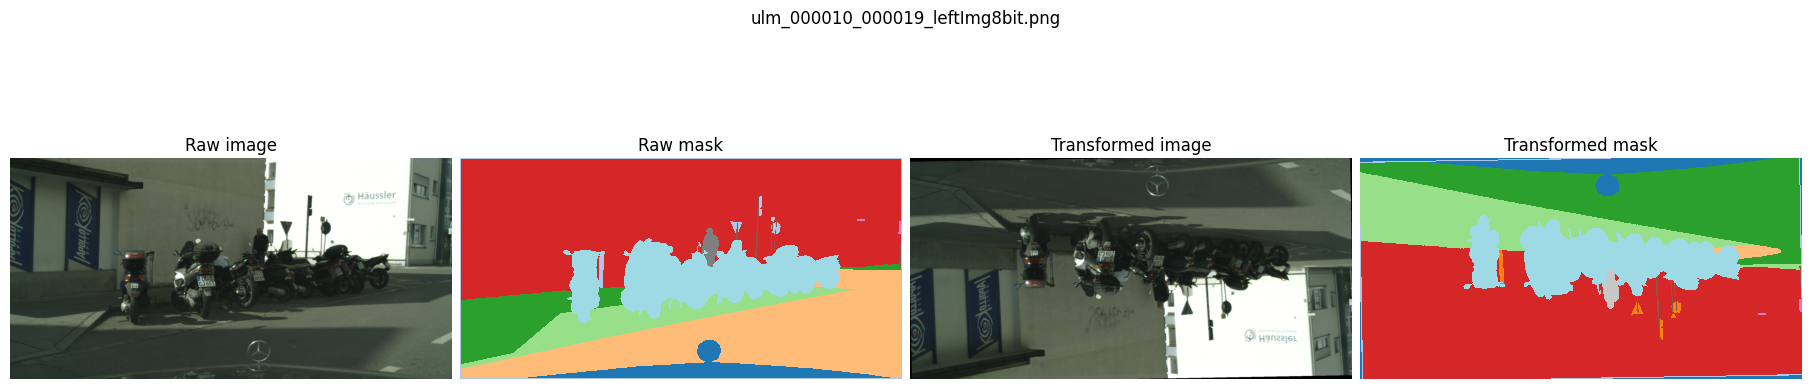

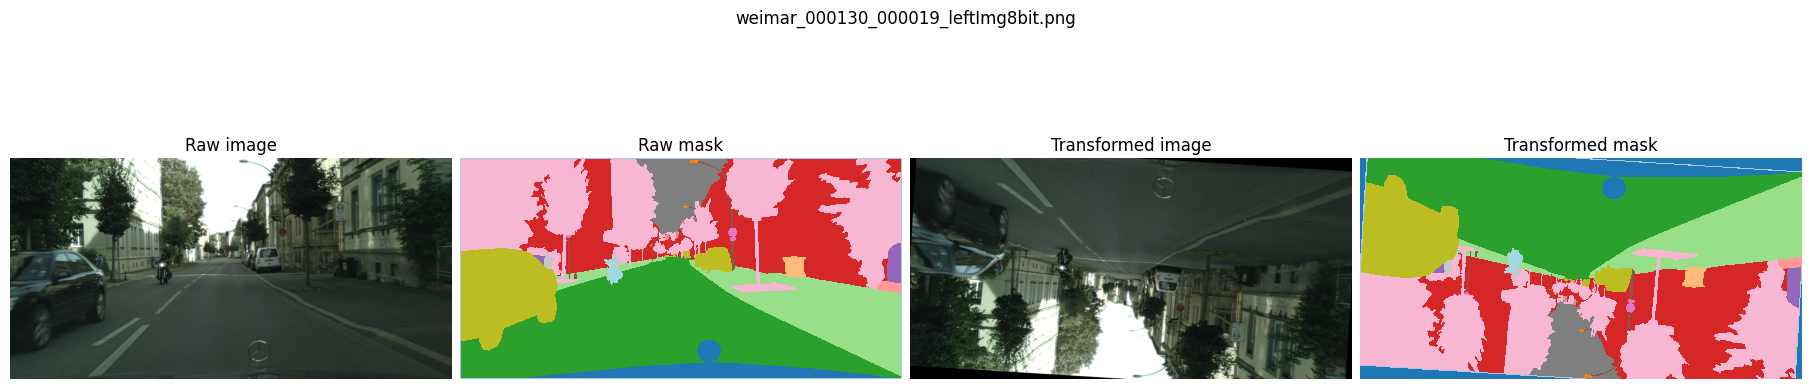

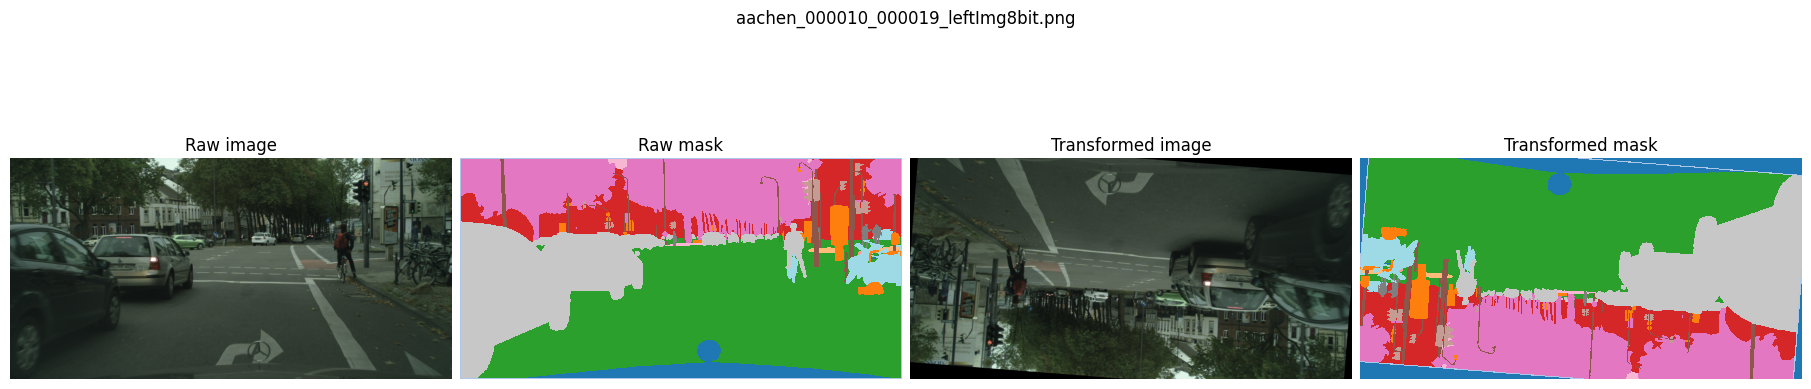

In [13]:
if available["Cityscapes root"]:
    print("=== Cityscapes geo-pair transform (3 random samples) ===")
    visualize_geo_pair_samples(cs_ds, num_samples=3, show=True)

=== Cityscapes batch collation test ===
  batch images — torch.Size([4, 3, 1024, 2048])  dtype: torch.float32
  batch masks  — torch.Size([4, 1024, 2048])  dtype: torch.int64
  unique class IDs in batch: [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 17, 18, 255]


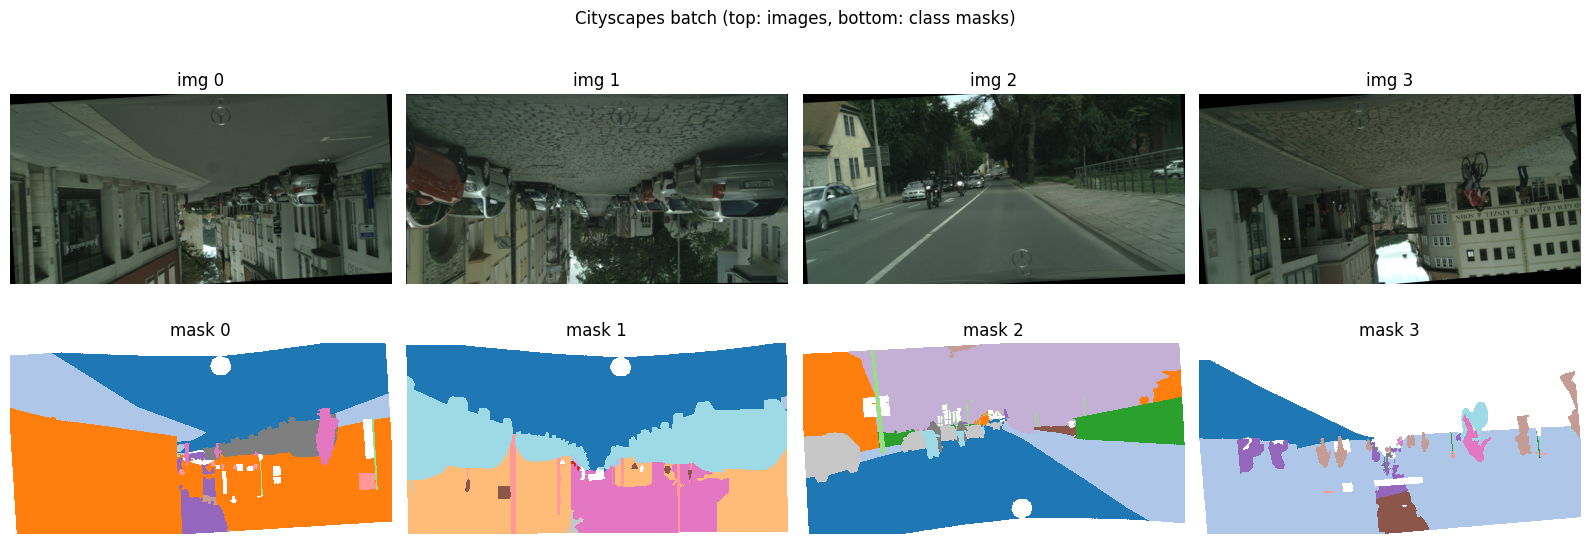

In [14]:
if available["Cityscapes root"]:
    print("=== Cityscapes batch collation test ===")
    cs_loader = DataLoader(
        cs_ds,
        batch_size=4,
        sampler=SequentialSampler(cs_ds),
        collate_fn=functools.partial(pad_collate, mask_pad_value=255),
    )
    imgs, masks, fnames = next(iter(cs_loader))
    print(f"  batch images — {imgs.shape}  dtype: {imgs.dtype}")
    print(f"  batch masks  — {masks.shape}  dtype: {masks.dtype}")
    print(f"  unique class IDs in batch: {torch.unique(masks).tolist()}")

    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    for i in range(4):
        axes[0, i].imshow(imgs[i].permute(1, 2, 0).clamp(0, 1))
        axes[0, i].set_title(f"img {i}")
        axes[0, i].axis("off")
        m = masks[i].float()
        m[m == 255] = float("nan")  # ignore index transparent
        axes[1, i].imshow(m.numpy(), cmap="tab20", interpolation="nearest")
        axes[1, i].set_title(f"mask {i}")
        axes[1, i].axis("off")
    plt.suptitle("Cityscapes batch (top: images, bottom: class masks)")
    plt.tight_layout()
    plt.show()

---
## 3. ADE20K (150-class semantic segmentation)

In [6]:
    ade_ds = ADE20KDataset(
        ADE20K_ROOT, split="train",
        gTransforms=geoTransforms,
        pTransforms=photometricTransforms,
    )

AttributeError: module 'torchvision.datasets' has no attribute 'ADE20K'

In [15]:
if not available["ADE20K root"]:
    print("ADE20K data not found — skipping")
else:
    ade_ds = ADE20KDataset(
        ADE20K_ROOT, split="train",
        gTransforms=geoTransforms,
        pTransforms=photometricTransforms,
    )
    print(f"ADE20K train: {len(ade_ds)} samples")

    img, mask, fname = ade_ds[0]
    print(f"  image  — shape: {img.shape}, dtype: {img.dtype}, range: [{img.min():.2f}, {img.max():.2f}]")
    print(f"  mask   — shape: {mask.shape}, dtype: {mask.dtype}")
    print(f"  unique class IDs (sample): {torch.unique(mask)[:20].tolist()} ...")
    print(f"  file   — {fname}")

ADE20K data not found — skipping


In [16]:
if available["ADE20K root"]:
    print("=== ADE20K geo-pair transform (3 random samples) ===")
    visualize_geo_pair_samples(ade_ds, num_samples=3, show=True)

In [17]:
if available["ADE20K root"]:
    print("=== ADE20K batch collation test ===")
    ade_loader = DataLoader(
        ade_ds,
        batch_size=4,
        sampler=SequentialSampler(ade_ds),
        collate_fn=functools.partial(pad_collate, mask_pad_value=255),
    )
    imgs, masks, fnames = next(iter(ade_loader))
    print(f"  batch images — {imgs.shape}  dtype: {imgs.dtype}")
    print(f"  batch masks  — {masks.shape}  dtype: {masks.dtype}")
    print(f"  unique class IDs in batch: {torch.unique(masks).tolist()[:20]} ...")

    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    for i in range(4):
        axes[0, i].imshow(imgs[i].permute(1, 2, 0).clamp(0, 1))
        axes[0, i].set_title(f"img {i}")
        axes[0, i].axis("off")
        m = masks[i].float()
        m[m == 255] = float("nan")
        axes[1, i].imshow(m.numpy(), cmap="tab20", interpolation="nearest")
        axes[1, i].set_title(f"mask {i}")
        axes[1, i].axis("off")
    plt.suptitle("ADE20K batch (top: images, bottom: class masks)")
    plt.tight_layout()
    plt.show()

---
## 4. Cross-dataset shape summary

In [18]:
print(f"{'Dataset':<15} {'Samples':>8} {'Img shape':>14} {'Mask shape':>12} {'Mask dtype':>12} {'Class range'}")
print("-" * 72)

entries = []
if available["CUB images"]:
    entries.append(("CUB", cub_ds))
if available["Cityscapes root"]:
    entries.append(("Cityscapes", cs_ds))
if available["ADE20K root"]:
    entries.append(("ADE20K", ade_ds))

for name, ds in entries:
    img, mask, _ = ds[0]
    uniq = torch.unique(mask)
    valid = uniq[uniq != 255]
    class_range = f"{valid.min().item()}–{valid.max().item()}" if len(valid) else "n/a"
    print(f"{name:<15} {len(ds):>8} {str(tuple(img.shape)):>14} {str(tuple(mask.shape)):>12} {str(mask.dtype):>12} {class_range}")

Dataset          Samples      Img shape   Mask shape   Mask dtype Class range
------------------------------------------------------------------------
CUB                11788  (3, 192, 320) (1, 192, 320) torch.float32 0.0–1.0
Cityscapes          2975 (3, 1024, 2048) (1024, 2048)  torch.int64 0–18
